# Task 1: Problem Identification

The given dataset represents an Image Classification problem in the field of computer vision.

The dataset contains images divided into four categories:
- normal
- scratch
- dent
- stain

Each image belongs to only one class, and the objective of the CNN model is to correctly classify the image into its respective category.

This is not an object detection problem because the dataset does not contain bounding boxes or object location coordinates. It is also not a segmentation problem because there are no pixel-level annotations or masks provided for the images.

Therefore, image classification is the most appropriate computer vision problem type for this dataset.

#Task 2: Dataset Exploration

In [9]:
# Import Required Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [10]:
import zipfile

with zipfile.ZipFile("images.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [11]:
import os

print(os.listdir("images"))

['.DS_Store', 'normal', 'stain', 'dent', 'scratch']


In [12]:
# Define Dataset Path
dataset_path = "images"

In [13]:
# Get Class Names
classes = []

for item in os.listdir(dataset_path):

    if item != ".DS_Store":
        classes.append(item)

print("Classes:")
print(classes)

Classes:
['normal', 'stain', 'dent', 'scratch']


In [14]:
# Number of Classes
print("Number of Classes:", len(classes))

Number of Classes: 4


In [15]:
# Count Images Per Class
for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    num_images = len(os.listdir(class_path))

    print(f"{class_name}: {num_images} images")

normal: 120 images
stain: 120 images
dent: 120 images
scratch: 120 images


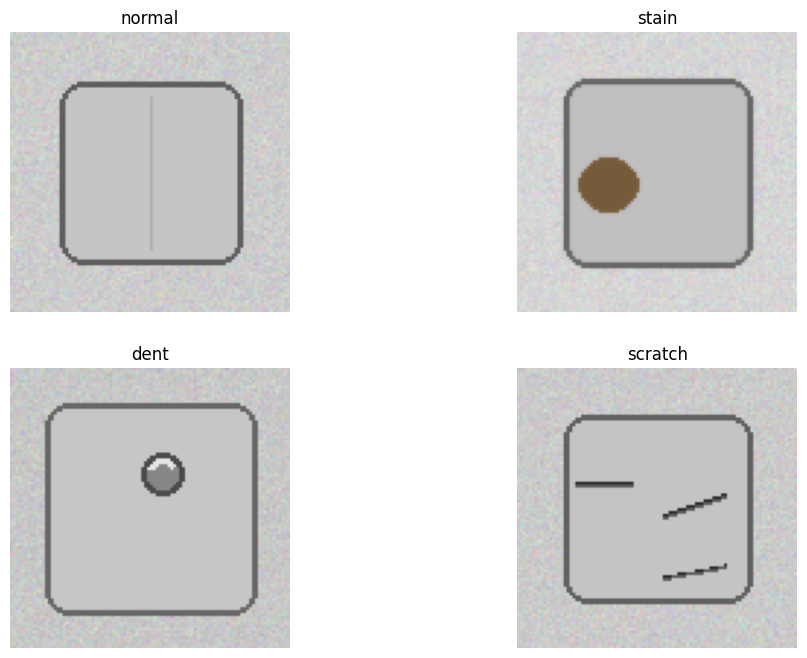

In [16]:
# Display Sample Images
plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, i+1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.show()

In [17]:
# Check Image Dimensions
sample_image_path = os.path.join(
    dataset_path,
    classes[0],
    os.listdir(os.path.join(dataset_path, classes[0]))[0]
)

sample_image = cv2.imread(sample_image_path)

print("Image Dimensions:", sample_image.shape)

Image Dimensions: (96, 96, 3)


# Task 3: Image Preprocessing

In [19]:
# Import TensorFlow
import tensorflow as tf

In [21]:
# Set Image Size and Batch Size
image_size = (128, 128)

batch_size = 32

In [22]:
# Load Training Dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="training",

    seed=42,

    image_size=image_size,

    batch_size=batch_size
)

Found 480 files belonging to 4 classes.
Using 384 files for training.


In [23]:
# Load Validation Dataset
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="validation",

    seed=42,

    image_size=image_size,

    batch_size=batch_size
)

Found 480 files belonging to 4 classes.
Using 96 files for validation.


In [24]:
# Display Class Names
class_names = train_dataset.class_names

print("Class Names:")
print(class_names)

Class Names:
['dent', 'normal', 'scratch', 'stain']


In [25]:
# Normalize Pixel Values
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [26]:
# Apply Normalization
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

In [28]:
# Apply Data Augmentation
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1)
])

#Task 4: CNN Model Creation

In [29]:
# Import Required Libraries
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [30]:
# Create CNN Model
model = Sequential()

In [31]:
# Add First Convolution Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# Add Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [33]:
# Add Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

In [34]:
# Add Second Pooling Layer
model.add(
    MaxPooling2D(pool_size=(2,2))
)

In [35]:
# Flatten Layer
model.add(Flatten())

In [36]:
# Dense Layer
model.add(
    Dense(
        128,
        activation='relu'
    )
)

In [37]:
# Dropout Layer
model.add(Dropout(0.5))

In [39]:
# Output Layer
model.add(
    Dense(
        4,
        activation='softmax'
    )
)

In [40]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
# Display Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,856 (28.20 MB)

 Trainable params: 7,392,856 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5: Model Training and Evaluation

In [42]:
# Train CNN Model
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 922ms/step - accuracy: 0.2396 - loss: 1.4080 - val_accuracy: 0.2396 - val_loss: 1.4260
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 864ms/step - accuracy: 0.2630 - loss: 1.4022 - val_accuracy: 0.2396 - val_loss: 1.4066
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2552 - loss: 1.3870 - val_accuracy: 0.2188 - val_loss: 1.3894
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3620 - loss: 1.3715 - val_accuracy: 0.5312 - val_loss: 1.3672
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 966ms/step - accuracy: 0.3958 - loss: 1.3316 - val_accuracy: 0.4167 - val_loss: 1.3102
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 794ms/step - accuracy: 0.4427 - loss: 1.2640 - val_accuracy: 0.4167 - val_loss: 1.2666
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 969ms/step - accuracy: 0.4557 - loss: 1.2213 - val_accuracy: 0.4583 - val_loss: 1.2458
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.4661 - loss: 1.1958 - val_accuracy: 0.3

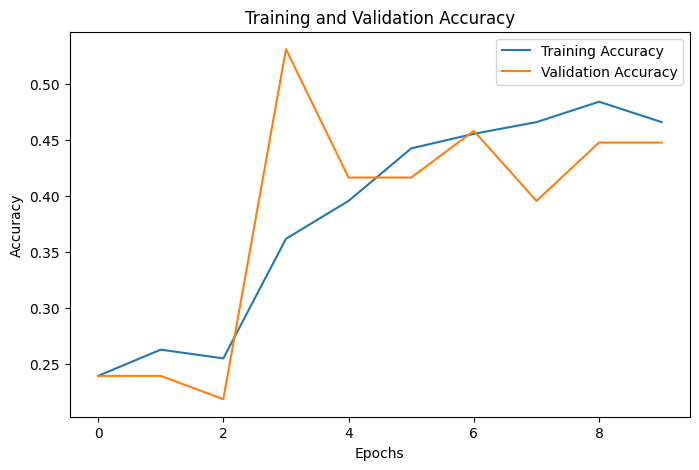

In [43]:
# Plot Accuracy Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training and Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

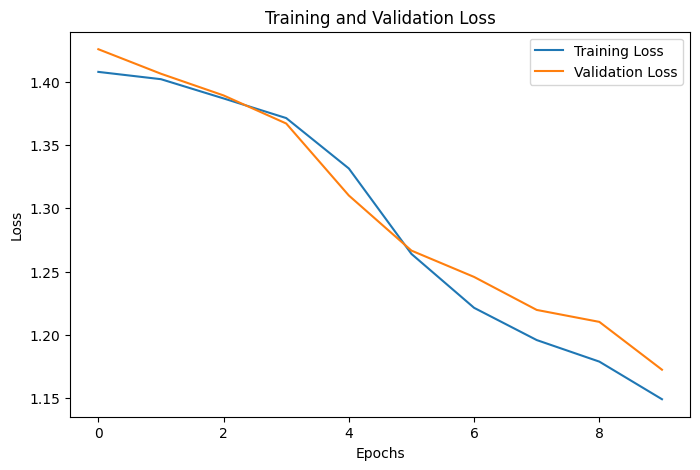

In [44]:
# Plot Loss Graph
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training and Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()


In [45]:
# Evaluate Model
test_loss, test_accuracy = model.evaluate(validation_dataset)

print("Testing Loss:", test_loss)

print("Testing Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 645ms/step - accuracy: 0.4479 - loss: 1.1723
Testing Loss: 1.1723361015319824
Testing Accuracy: 0.4479166567325592


In [46]:
# Import Required Libraries
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [47]:
# Get True Labels and Predictions
y_true = []

y_pred = []

for images, labels in validation_dataset:

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step


In [48]:
# Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

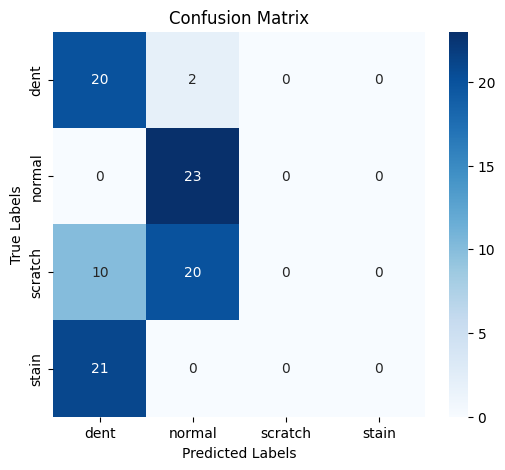

In [49]:
# Display Confusion Matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step


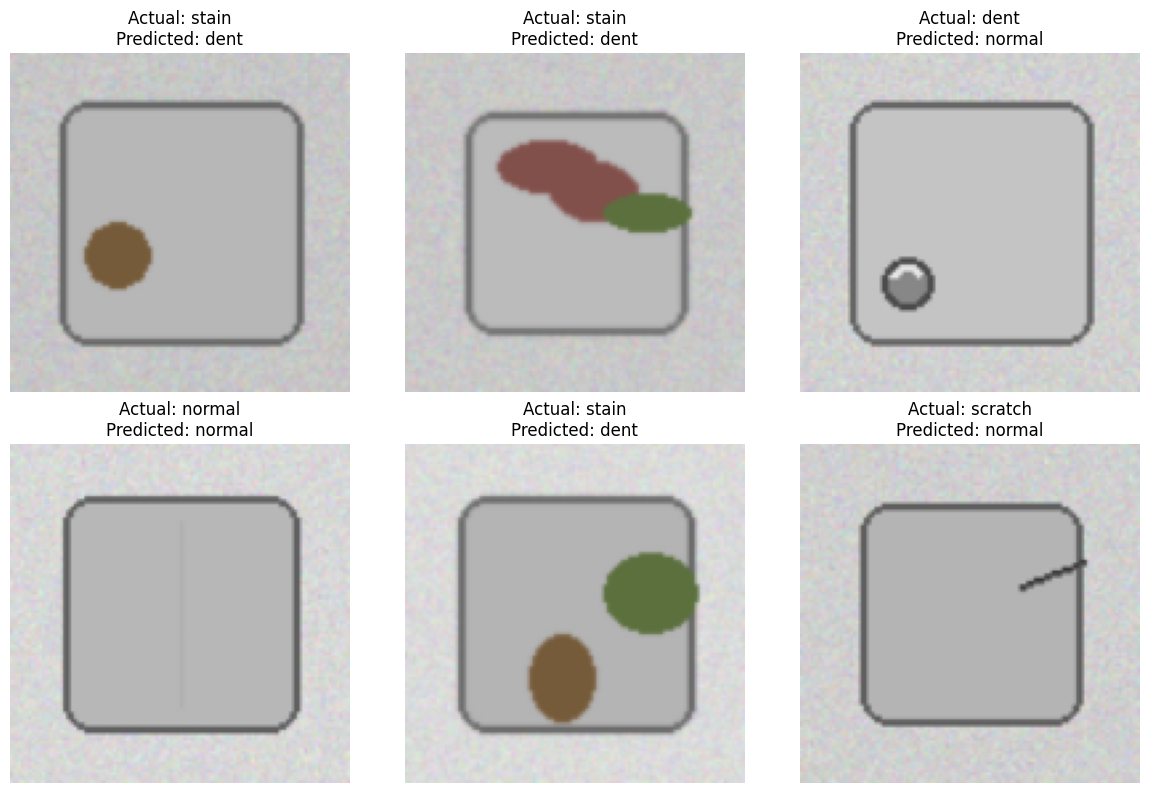

In [50]:
# Display Sample Predictions
plt.figure(figsize=(12,8))

for images, labels in validation_dataset.take(1):

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(6):

        plt.subplot(2,3,i+1)

        plt.imshow(images[i].numpy())

        plt.title(
            f"Actual: {class_names[labels[i]]}\nPredicted: {class_names[predicted_labels[i]]}"
        )

        plt.axis("off")

plt.tight_layout()

plt.show()

# Task 7: Business Use Case Mapping

This type of computer vision solution can be widely used in the manufacturing industry for automated quality inspection.

In manufacturing plants, CNN-based image classification systems can analyze product surface images and detect defects such as scratches, dents, and stains automatically.  
This helps companies improve product quality, reduce manual inspection effort, minimize human error, and increase production efficiency.

Such systems can operate in real-time on assembly lines and quickly identify defective products before they are shipped to customers.